# 🍎🥑🍌 TCS34725 센서 데이터 기반 MLP 과일 분류

**목표**: 실제 RGB 센서(TCS34725)로 측정한 데이터를 사용하여 MLP 모델 학습

**데이터**: 과일 3종 × 10회 측정 = 30개 샘플
- 🍌 Banana: 10개
- 🥑 Avocado: 10개  
- 🍎 Apple Red: 10개

**모델**: PyTorch MLP (3 → 64 → 32 → 3)

In [2]:
# 필요한 라이브러리 import
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os


In [ ]:
#실제 TCS34725 센서 측정 데이터 (2026.01.20)



banana_data = [
    (81, 119, 54),
    (82, 120, 51),
    (84, 121, 48),
    (84, 121, 48),
    (84, 121, 48),
    (85, 121, 48),
    (85, 121, 48),
    (75, 112, 66),
    (75, 112, 67),
    (72, 111, 70),
]


avocado_data = [
    (56, 123, 75),
    (56, 123, 75),
    (56, 123, 75),
    (56, 123, 75),
    (56, 122, 75),
    (56, 123, 75),
    (56, 123, 75),
    (56, 123, 75),
    (56, 123, 75),
    (56, 123, 74),
]


apple_data = [
    (145, 58, 52),
    (141, 59, 53),
    (140, 60, 53),
    (142, 59, 53),
    (143, 58, 52),
    (147, 56, 50),
    (145, 57, 51),
    (143, 58, 52),
    (140, 60, 54),
    (90, 84, 80)
]

# 데이터프레임 생성
data = []
for r, g, b in banana_data:
    data.append({'R': r, 'G': g, 'B': b, 'label': 'Banana'})
for r, g, b in avocado_data:
    data.append({'R': r, 'G': g, 'B': b, 'label': 'Avocado'})
for r, g, b in apple_data:
    data.append({'R': r, 'G': g, 'B': b, 'label': 'Apple Red'})

df = pd.DataFrame(data)
print("="*50)
print("📊 센서 데이터 요약")
print("="*50)
print(f"총 샘플 수: {len(df)}")
print(f"\n클래스별 분포:")
print(df['label'].value_counts())
print(f"\n데이터 미리보기:")
df

📊 센서 데이터 요약
총 샘플 수: 30

클래스별 분포:
label
Banana       10
Avocado      10
Apple Red    10
Name: count, dtype: int64

데이터 미리보기:


,R,G,B,label
0,81,119,54,Banana
1,82,120,51,Banana
2,84,121,48,Banana
3,84,121,48,Banana
4,84,121,48,Banana
5,85,121,48,Banana
6,85,121,48,Banana
7,75,112,66,Banana
8,75,112,67,Banana
9,72,111,70,Banana


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_17156\161226434.py:37: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_17156\161226434.py:37: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_17156\161226434.py:37: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_17156\161226434.py:37: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE

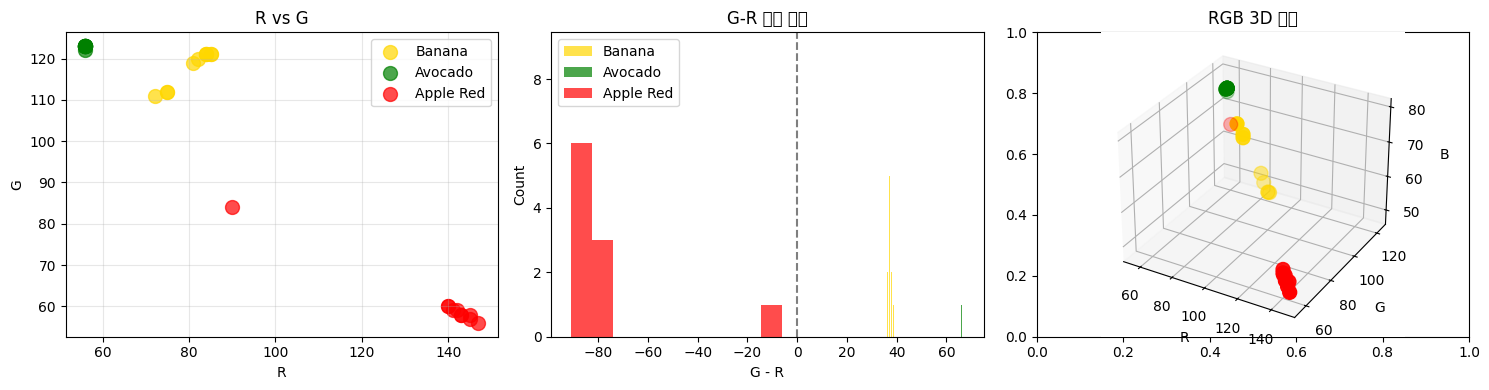


📊 클래스별 RGB 통계:
               R                     G                    B               \
            mean   std min  max   mean  std  min  max  mean  std min max   
label                                                                      
Apple Red  137.6  16.9  90  147   60.9  8.2   56   84  55.0  8.9  50  80   
Avocado     56.0   0.0  56   56  122.9  0.3  122  123  74.9  0.3  74  75   
Banana      80.7   4.9  72   85  117.9  4.4  111  121  54.8  9.1  48  70   

            G-R                
           mean   std min max  
label                          
Apple Red -76.7  25.1 -91  -6  
Avocado    66.9   0.3  66  67  
Banana     37.2   0.9  36  39  


In [4]:
# 📈 데이터 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'Apple Red': 'red', 'Avocado': 'green', 'Banana': 'gold'}

# R vs G 산점도
for label in df['label'].unique():
    subset = df[df['label'] == label]
    axes[0].scatter(subset['R'], subset['G'], c=colors[label], label=label, s=100, alpha=0.7)
axes[0].set_xlabel('R')
axes[0].set_ylabel('G')
axes[0].set_title('R vs G')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# G-R 차이 분포
df['G-R'] = df['G'] - df['R']
for label in df['label'].unique():
    subset = df[df['label'] == label]
    axes[1].hist(subset['G-R'], bins=10, color=colors[label], alpha=0.7, label=label)
axes[1].set_xlabel('G - R')
axes[1].set_ylabel('Count')
axes[1].set_title('G-R 차이 분포')
axes[1].legend()
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# 3D 산점도
ax3d = fig.add_subplot(1, 3, 3, projection='3d')
for label in df['label'].unique():
    subset = df[df['label'] == label]
    ax3d.scatter(subset['R'], subset['G'], subset['B'], c=colors[label], label=label, s=100)
ax3d.set_xlabel('R')
ax3d.set_ylabel('G')
ax3d.set_zlabel('B')
ax3d.set_title('RGB 3D 분포')

plt.tight_layout()
plt.show()

# 통계 요약
print("\n📊 클래스별 RGB 통계:")
print(df.groupby('label')[['R', 'G', 'B', 'G-R']].agg(['mean', 'std', 'min', 'max']).round(1))

In [5]:
# 🔧 데이터 전처리
print("="*50)
print("Data Preprocessing")
print("="*50)

# Feature와 Label 분리
X = df[['R', 'G', 'B']].values.astype(np.float32)
y = df['label'].values

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"클래스: {le.classes_}")
print(f"인코딩: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 정규화 (0-255 → 0-1)
X_norm = X / 255.0

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

print(f"\nX shape: {X_scaled.shape}")
print(f"X mean: {X_scaled.mean(axis=0).round(4)}")
print(f"X std: {X_scaled.std(axis=0).round(4)}")

Data Preprocessing
클래스: ['Apple Red' 'Avocado' 'Banana']
인코딩: {'Apple Red': 0, 'Avocado': 1, 'Banana': 2}

X shape: (30, 3)
X mean: [-0.  0.  0.]
X std: [1. 1. 1.]


In [6]:
# 📊 Train/Test 분할 (80/20)
# 데이터가 적으므로 stratify 사용하여 클래스 비율 유지
print("="*50)
print("Train/Test Split")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Train: {X_train.shape[0]}개 ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]}개 ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"\nTrain 클래스 분포: {np.bincount(y_train)}")
print(f"Test 클래스 분포:  {np.bincount(y_test)}")

# PyTorch 텐서로 변환
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# DataLoader (배치 사이즈는 작게 - 데이터가 적으므로)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("\n✓ DataLoader 생성 완료")

Train/Test Split
Train: 24개 (80%)
Test:  6개 (20%)

Train 클래스 분포: [8 8 8]
Test 클래스 분포:  [2 2 2]

✓ DataLoader 생성 완료


In [7]:
# 🧠 MLP 모델 정의 (작은 모델 - 데이터가 적으므로)
class SensorMLP(nn.Module):
    def __init__(self, input_dim=3, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

# 모델 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SensorMLP(input_dim=3, num_classes=3).to(device)

print(f"Device: {device}")
print(f"\n모델 구조:")
print(model)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n총 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

Device: cuda

모델 구조:
SensorMLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)

총 파라미터: 2,435
학습 가능 파라미터: 2,435


In [8]:
# 🎯 모델 학습
print("="*50)
print("Training")
print("="*50)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

num_epochs = 300
train_losses = []
train_accs = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    
    scheduler.step()
    
    avg_loss = epoch_loss / len(train_loader)
    accuracy = 100. * correct / total
    train_losses.append(avg_loss)
    train_accs.append(accuracy)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | Loss: {avg_loss:.4f} | Acc: {accuracy:.1f}%")

print(f"\n✓ 학습 완료! 최종 정확도: {train_accs[-1]:.1f}%")

Training
Epoch [ 50/300] | Loss: 0.0012 | Acc: 100.0%
Epoch [100/300] | Loss: 0.0001 | Acc: 100.0%
Epoch [150/300] | Loss: 0.0001 | Acc: 100.0%
Epoch [200/300] | Loss: 0.0024 | Acc: 100.0%
Epoch [250/300] | Loss: 0.0004 | Acc: 100.0%
Epoch [300/300] | Loss: 0.0010 | Acc: 100.0%

✓ 학습 완료! 최종 정확도: 100.0%


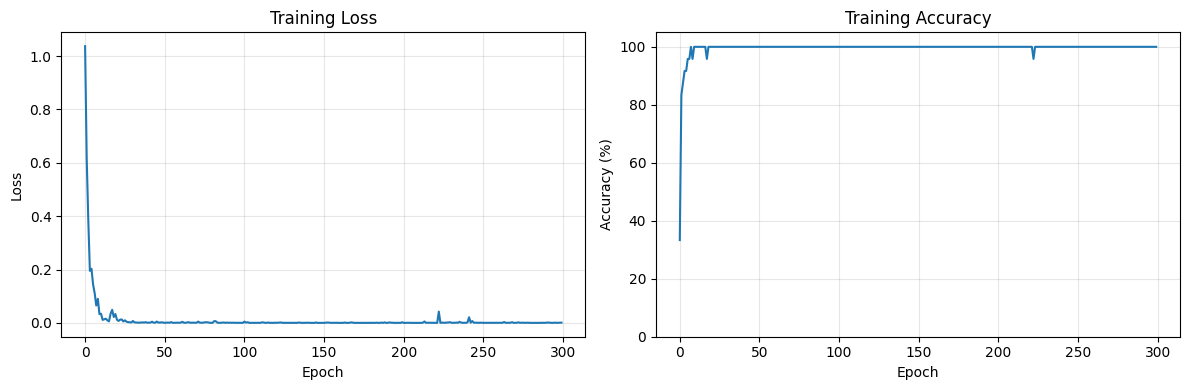

In [9]:
# 📈 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

Test Evaluation
Test Accuracy: 100.00%

Confusion Matrix:
[[2 0 0]
 [0 2 0]
 [0 0 2]]

Classification Report:
              precision    recall  f1-score   support

   Apple Red       1.00      1.00      1.00         2
     Avocado       1.00      1.00      1.00         2
      Banana       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



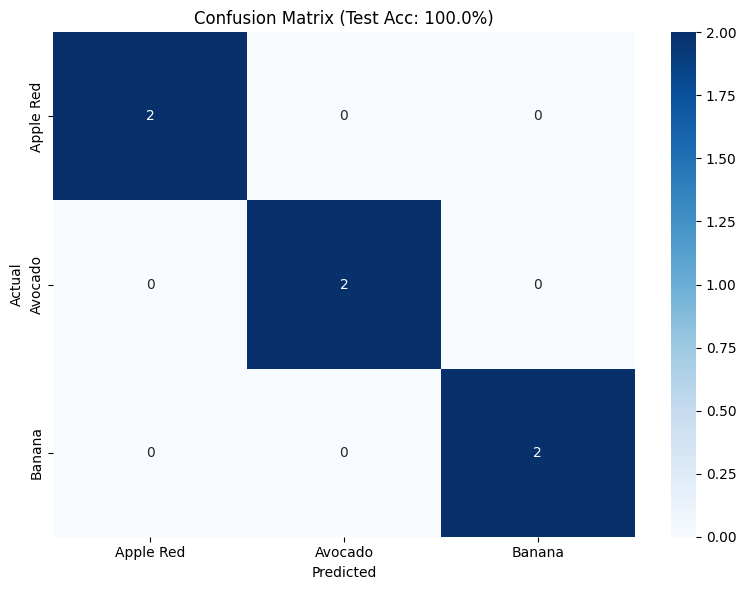

In [10]:
# 🧪 테스트 세트 평가
print("="*50)
print("Test Evaluation")
print("="*50)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 정확도
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.2%}")

# 혼동 행렬
cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Acc: {test_acc:.1%})')
plt.tight_layout()
plt.show()

In [13]:
# 📋 전체 데이터로 검증
print("="*50)
print("전체 데이터 검증 (30개 샘플)")
print("="*50)

model.eval()
X_all = torch.FloatTensor(X_scaled).to(device)

with torch.no_grad():
    outputs = model(X_all)
    probs = torch.softmax(outputs, dim=1)
    _, predictions = outputs.max(1)

predictions = predictions.cpu().numpy()
probs = probs.cpu().numpy()

# 결과 출력
print(f"\n{'#':>3} | {'실제':<12} | {'예측':<12} | {'신뢰도':>8} | {'결과'}")
print("-" * 55)

correct = 0
for i in range(len(df)):
    actual = le.classes_[y_encoded[i]]
    predicted = le.classes_[predictions[i]]
    confidence = probs[i][predictions[i]]
    is_correct = actual == predicted
    if is_correct:
        correct += 1
    result = "✅" if is_correct else "❌"
    emoji = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}[actual]
    print(f"{i+1:3} | {emoji} {actual:<10} | {predicted:<12} | {confidence:7.1%} | {result}")

print("-" * 55)
print(f"전체 정확도: {correct}/{len(df)} = {correct/len(df):.1%}")

전체 데이터 검증 (30개 샘플)

  # | 실제           | 예측           |      신뢰도 | 결과
-------------------------------------------------------
  1 | 🍌 Banana     | Banana       |  100.0% | ✅
  2 | 🍌 Banana     | Banana       |  100.0% | ✅
  3 | 🍌 Banana     | Banana       |  100.0% | ✅
  4 | 🍌 Banana     | Banana       |  100.0% | ✅
  5 | 🍌 Banana     | Banana       |  100.0% | ✅
  6 | 🍌 Banana     | Banana       |  100.0% | ✅
  7 | 🍌 Banana     | Banana       |  100.0% | ✅
  8 | 🍌 Banana     | Banana       |  100.0% | ✅
  9 | 🍌 Banana     | Banana       |  100.0% | ✅
 10 | 🍌 Banana     | Banana       |   99.8% | ✅
 11 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 12 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 13 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 14 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 15 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 16 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 17 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 18 | 🥑 Avocado    | Avocado      |  100.0% | ✅
 19 | 🥑 Av

In [14]:
# 💾 모델 저장
print("="*50)
print("Model Saving")
print("="*50)

save_dir = "sensor_model"
os.makedirs(save_dir, exist_ok=True)

# 1. 모델 가중치 저장
torch.save(model.state_dict(), f"{save_dir}/sensor_mlp_weights.pth")

# 2. 전체 모델 저장
torch.save(model, f"{save_dir}/sensor_mlp_full.pth")

# 3. Scaler 저장
joblib.dump(scaler, f"{save_dir}/scaler.joblib")

# 4. LabelEncoder 저장
joblib.dump(le, f"{save_dir}/label_encoder.joblib")

# 5. 모델 정보 저장
model_info = {
    "input_dim": 3,
    "num_classes": 3,
    "class_names": list(le.classes_),
    "train_accuracy": train_accs[-1] / 100,
    "test_accuracy": test_acc,
    "num_samples": len(df),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "architecture": "3 → 64 → 32 → 3",
}

with open(f"{save_dir}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(f"✓ 저장 완료: {save_dir}/")
for f in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{f}") / 1024
    print(f"  - {f}: {size:.1f} KB")

Model Saving
✓ 저장 완료: sensor_model/
  - label_encoder.joblib: 0.5 KB
  - model_info.json: 0.4 KB
  - scaler.joblib: 0.6 KB
  - sensor_mlp_full.pth: 14.5 KB
  - sensor_mlp_weights.pth: 12.7 KB


In [17]:
# 🔮 추론 함수 정의
CLASS_NAMES = list(le.classes_)

def classify_fruit(r, g, b):
    """
    RGB 값을 받아 딥러닝 모델로 과일 분류
    
    Args:
        r, g, b: RGB 값 (0~255)
    
    Returns:
        tuple: (과일 이름, 신뢰도, 모든 클래스 확률)
    """
    # 전처리
    x = np.array([[r, g, b]], dtype=np.float32) / 255.0
    x = scaler.transform(x)
    
    # 추론
    x_tensor = torch.FloatTensor(x).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()
    
    label = CLASS_NAMES[pred_idx]
    all_probs = {CLASS_NAMES[i]: probs[0, i].item() for i in range(3)}
    
    return label, confidence, all_probs

# 테스트
print("="*60)
print("🔮 추론 함수 테스트")
print("="*60)

test_cases = [
    (81, 119, 54, "Banana"),
    (56, 123, 75, "Avocado"),
    (145, 58, 52, "Apple Red"),
    (90, 84, 80, "Apple Red (outlier)"),
]

print(f"\n{'RGB':^15} | {'예측':^12} | {'신뢰도':>8} | {'정답'}")
print("-" * 55)
for r, g, b, expected in test_cases:
    label, conf, probs = classify_fruit(r, g, b)
    emoji = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}[label]
    print(f"({r:3},{g:3},{b:3}) | {emoji} {label:<10} | {conf:7.1%} | {expected}")

🔮 추론 함수 테스트

      RGB       |      예측      |      신뢰도 | 정답
-------------------------------------------------------
( 81,119, 54) | 🍌 Banana     |  100.0% | Banana
( 56,123, 75) | 🥑 Avocado    |  100.0% | Avocado
(145, 58, 52) | 🍎 Apple Red  |  100.0% | Apple Red
( 90, 84, 80) | 🍎 Apple Red  |  100.0% | Apple Red (outlier)


In [18]:
# 🚀 시리얼 통신 코드 (아두이노 연결용)
import serial
import serial.tools.list_ports
import time

# 포트 확인
print("사용 가능한 시리얼 포트:")
for port in serial.tools.list_ports.comports():
    print(f"  • {port.device}: {port.description}")

사용 가능한 시리얼 포트:
  • COM3: USB-SERIAL CH340(COM3)


In [19]:
# ⚠️ 시리얼 통신 설정
SERIAL_PORT = "COM3"  # 실제 포트로 변경
BAUD_RATE = 9600

In [22]:
# 🚀 실시간 분류 실행
def run_classification():
    """아두이노에서 RGB 값을 받아 실시간 분류 (엔터 입력 시 1회 측정)"""
    
    try:
        ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=1)
        print(f"✓ 연결됨: {SERIAL_PORT} @ {BAUD_RATE} baud")
        print("="*60)
        print("📌 사용법: 엔터를 누르면 RGB 1회 측정 후 분류합니다.")
        print("📌 종료: 'q' 입력 후 엔터")
        print("="*60)
        
        time.sleep(1)
        ser.reset_input_buffer()
        count = 0
        
        while True:
            user_input = input("\n[엔터] 측정 시작 (q: 종료) > ").strip().lower()
            
            if user_input == 'q':
                print("\n👋 프로그램 종료")
                break
            
            ser.reset_input_buffer()
            print("\n⏳ 측정 중...")
            
            start_time = time.time()
            while time.time() - start_time < 2.0:
                if ser.in_waiting > 0:
                    line = ser.readline().decode('utf-8', errors='ignore').strip()
                    if line:
                        parts = line.split(',')
                        if len(parts) == 3:
                            r, g, b = map(float, parts)
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                label, conf, probs = classify_fruit(r, g, b)
                                count += 1
                                
                                emoji = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}[label]
                                
                                print(f"\n{'='*60}")
                                print(f"📊 측정 결과 #{count}")
                                print(f"{'-'*60}")
                                print(f"  측정 RGB: ({r:.0f}, {g:.0f}, {b:.0f})")
                                print(f"  G - R 차이: {g - r:.0f}")
                                print(f"{'-'*60}")
                                print(f"  🎯 분류 결과: {emoji} {label}")
                                print(f"  📈 신뢰도: {conf:.1%}")
                                print(f"{'-'*60}")
                                print("  확률 분포:")
                                for fruit, prob in sorted(probs.items(), key=lambda x: -x[1]):
                                    bar = "█" * int(prob * 20)
                                    e = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}[fruit]
                                    print(f"    {e} {fruit:12s} {bar} {prob:.1%}")
                                print(f"{'='*60}")
                                break
                time.sleep(0.01)
            else:
                print("\n⚠️ 데이터를 수신하지 못했습니다.")
                
    except serial.SerialException as e:
        print(f"✗ 연결 실패: {e}")
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print(f"\n✓ 연결 종료 (총 {count}회 측정)")

# 실행
run_classification()

✓ 연결됨: COM3 @ 9600 baud
📌 사용법: 엔터를 누르면 RGB 1회 측정 후 분류합니다.
📌 종료: 'q' 입력 후 엔터

⏳ 측정 중...

📊 측정 결과 #1
------------------------------------------------------------
  측정 RGB: (85, 108, 60)
  G - R 차이: 23
------------------------------------------------------------
  🎯 분류 결과: 🍌 Banana
  📈 신뢰도: 100.0%
------------------------------------------------------------
  확률 분포:
    🍌 Banana       ███████████████████ 100.0%
    🍎 Apple Red     0.0%
    🥑 Avocado       0.0%

⏳ 측정 중...

📊 측정 결과 #2
------------------------------------------------------------
  측정 RGB: (54, 139, 61)
  G - R 차이: 85
------------------------------------------------------------
  🎯 분류 결과: 🥑 Avocado
  📈 신뢰도: 50.8%
------------------------------------------------------------
  확률 분포:
    🥑 Avocado      ██████████ 50.8%
    🍌 Banana       █████████ 49.2%
    🍎 Apple Red     0.0%

⏳ 측정 중...

📊 측정 결과 #3
------------------------------------------------------------
  측정 RGB: (50, 145, 58)
  G - R 차이: 95
-----------------------------